# 2. Linear Regression

#Objective: Implement and interpret linear regression using scikit-learn


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Creating sample data
data = {
    'Experience': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Salary': [30, 35, 40, 45, 50, 55, 60, 65, 70, 75]
}
df = pd.DataFrame(data)

# Splitting features and target
X = df[['Experience']]  # Independent variable
y = df['Salary']  # Dependent variable

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [5]:
y_pred = model.predict(X_test)

In [6]:
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")
print(f"R² Score: {r2_score(y_test, y_pred)}")

Mean Squared Error: 0.0
R² Score: 1.0


# 3. Logistic Regression for Binary Classification

Objective: Build and evaluate a logistic regression classifier



In [7]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [8]:
# Sample dataset
data = {
    'Age': [25, 30, 35, 40, 45, 50, 55, 60, 65, 70],
    'Has_Disease': [0, 0, 0, 0, 1, 1, 1, 1, 1, 1]  # Binary classification (0 = No Disease, 1 = Disease)
}
df = pd.DataFrame(data)

# Splitting features and target
X = df[['Age']]
y = df['Has_Disease']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [11]:
y_pred = model.predict(X_test)

In [12]:
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

Accuracy Score: 1.0
Confusion Matrix:
[[1 0]
 [0 1]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         1

    accuracy                           1.00         2
   macro avg       1.00      1.00      1.00         2
weighted avg       1.00      1.00      1.00         2



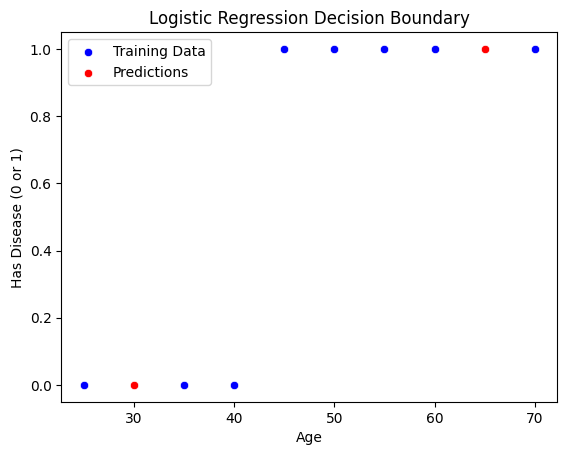

In [13]:
import seaborn as sns

sns.scatterplot(x=X_train['Age'], y=y_train, color='blue', label="Training Data")
sns.scatterplot(x=X_test['Age'], y=y_pred, color='red', label="Predictions")
plt.xlabel("Age")
plt.ylabel("Has Disease (0 or 1)")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()

 # Cross-Validation Technique

Objective: Implement k-fold using cross_val_score



In [15]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris

In [16]:
data = load_iris()
X = data.data  # Features
y = data.target  # Target variable

In [17]:
model = LogisticRegression(max_iter=2000)

In [18]:
scores = cross_val_score(model, X, y, cv=5)  # cv=5 means 5 folds
print(f"Cross-validation scores: {scores}")
print(f"Mean Accuracy: {np.mean(scores):.4f}")

Cross-validation scores: [0.96666667 1.         0.93333333 0.96666667 1.        ]
Mean Accuracy: 0.9733


# Ridge and Lasso Regression

Objective: Demonstrate regularization techniques on linear models.



In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error

In [20]:
# Sample dataset
np.random.seed(42)
X = np.random.rand(100, 5) * 10  # 5 Features
y = 3 * X[:, 0] + 2 * X[:, 1] + X[:, 2] - X[:, 3] + np.random.randn(100) * 2  # True relationship

# Splitting into train & test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
ridge = Ridge(alpha=1.0)  # alpha controls regularization strength
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

print(f"Ridge MSE: {mean_squared_error(y_test, ridge_pred):.4f}")
print(f"Ridge Coefficients: {ridge.coef_}")

Ridge MSE: 3.8973
Ridge Coefficients: [ 2.92562699  1.95017121  1.12750878 -0.96927148 -0.08992247]


In [22]:

lasso = Lasso(alpha=0.1)  # Lasso regularization strength
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

print(f"Lasso MSE: {mean_squared_error(y_test, lasso_pred):.4f}")
print(f"Lasso Coefficients: {lasso.coef_}")

Lasso MSE: 3.8410
Lasso Coefficients: [ 2.91564036  1.94250358  1.11777823 -0.96194533 -0.08268714]


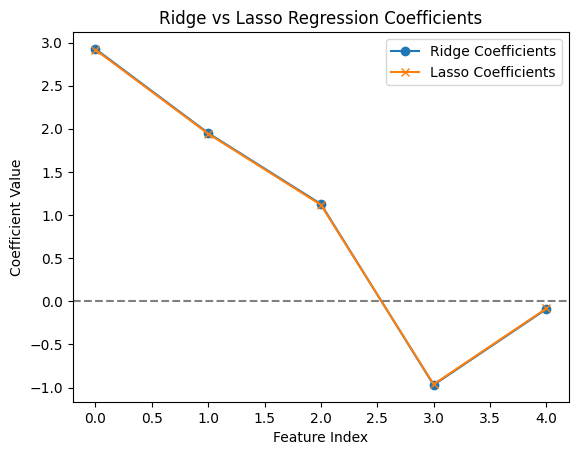

In [23]:
plt.plot(ridge.coef_, label="Ridge Coefficients", marker='o')
plt.plot(lasso.coef_, label="Lasso Coefficients", marker='x')
plt.axhline(0, linestyle='--', color='gray')
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.legend()
plt.title("Ridge vs Lasso Regression Coefficients")
plt.show()

# Dimension Reduction using PCA

Objective: Reduce dimensionality and visualize principal components.



In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_digits

In [25]:
digits = load_digits()
X = digits.data  # Features
y = digits.target  # Labels

# Standardizing the Data (PCA performs best when data is standardized)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [26]:
pca = PCA(n_components=2)  # Reduce to 2 dimensions
X_pca = pca.fit_transform(X_scaled)
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")

Explained Variance Ratio: [0.12033916 0.09561054]


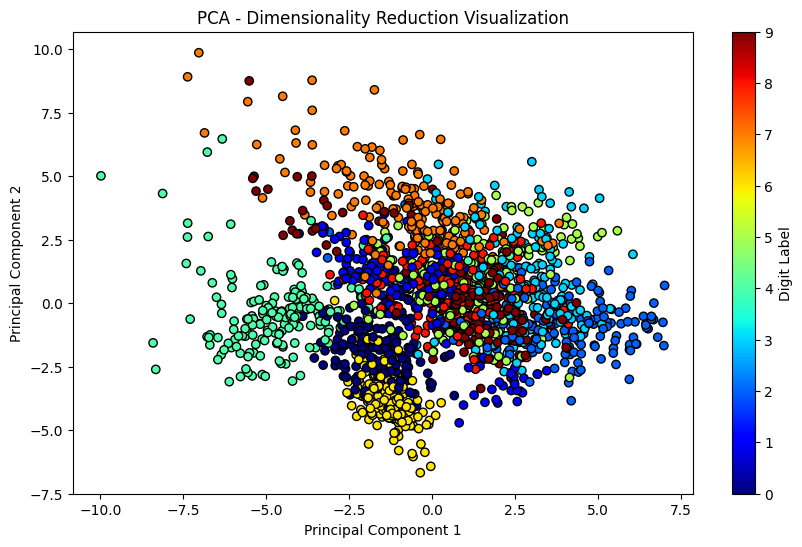

In [27]:
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='jet', edgecolors='k')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Dimensionality Reduction Visualization")
plt.colorbar(label="Digit Label")
plt.show()

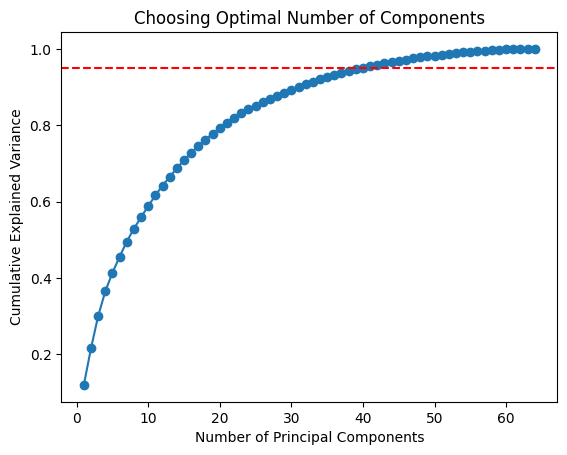

In [28]:
pca_all = PCA().fit(X_scaled)
plt.plot(range(1, X_scaled.shape[1] + 1), np.cumsum(pca_all.explained_variance_ratio_), marker='o')
plt.axhline(y=0.95, color='r', linestyle='--')  # 95% variance threshold
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Choosing Optimal Number of Components")
plt.show()

# Decision Trees – Classification

Objective: Implement and visualize decision trees.



In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_iris

In [30]:
data = load_iris()
X = data.data  # Features
y = data.target  # Labels (Setosa, Versicolor, Virginica)

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
model = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [33]:
y_pred = model.predict(X_test)

In [34]:
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"Classification Report:\n{classification_report(y_test, y_pred)}")

Accuracy Score: 1.0000
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



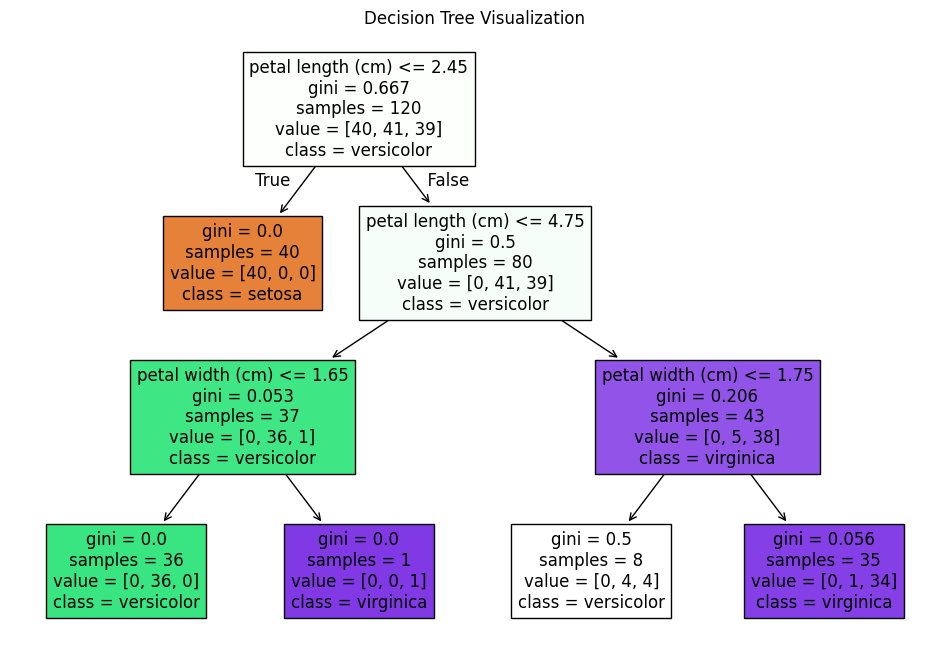

In [35]:
plt.figure(figsize=(12, 8))
plot_tree(model, feature_names=data.feature_names, class_names=data.target_names, filled=True)
plt.title("Decision Tree Visualization")
plt.show()

In [37]:
model = DecisionTreeClassifier(max_depth=5, min_samples_split=5, min_samples_leaf=3)

# Ensemble Method – Random Forest

Objective: Compare accuracy of Random Forest with Decision Tree.



In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_iris

In [39]:
data = load_iris()
X = data.data  # Features
y = data.target  # Labels (Setosa, Versicolor, Virginica)

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

In [42]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [43]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

Decision Tree Accuracy: 1.0000
Random Forest Accuracy: 1.0000


In [44]:
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))

print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Support Vector Classifier (SVC)

Objective: Apply SVC for binary classification.



In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import make_classification

In [48]:
X, y = make_classification(n_samples=200, n_features=2, n_classes=2, random_state=42)

ValueError: Number of informative, redundant and repeated features must sum to less than the number of total features